# Seaborn #

In [331]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Statistics
from scipy.stats import norm

# Plots
import seaborn as sns
import matplotlib.pyplot as plt

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from data_downloader import get_market_data

In [332]:
tickers = get_tickers("7.2a")

tickers

['META', 'MSFT', 'TSLA']

In [333]:
# DataFrame to store everything
returns_df = pd.DataFrame()

for ticker in tickers:
    df_stock = get_market_data(
        ticker=ticker, 
        start_date='2015-01-01', 
        end_date='2025-01-01', 
        returns=True
    )
    
    returns = df_stock['returns'].rename(ticker)
    
    returns_df = pd.concat([returns_df, returns], axis=1)

In [334]:
# Dates
returns_df.index = pd.to_datetime(returns_df.index)
returns_df

,META,MSFT,TSLA
2015-01-05,-0.016191,-0.009238,-0.042950
2015-01-06,-0.013565,-0.014786,0.005648
2015-01-07,0.000000,0.012625,-0.001563
2015-01-08,0.026309,0.028994,-0.001566
2015-01-09,-0.005644,-0.008441,-0.018981
...,...,...,...
2024-12-24,0.013084,0.009330,0.070991
2024-12-26,-0.007266,-0.002781,-0.017787
2024-12-27,-0.005885,-0.017453,-0.050745
2024-12-30,-0.014391,-0.013328,-0.033569


### Distributions ###

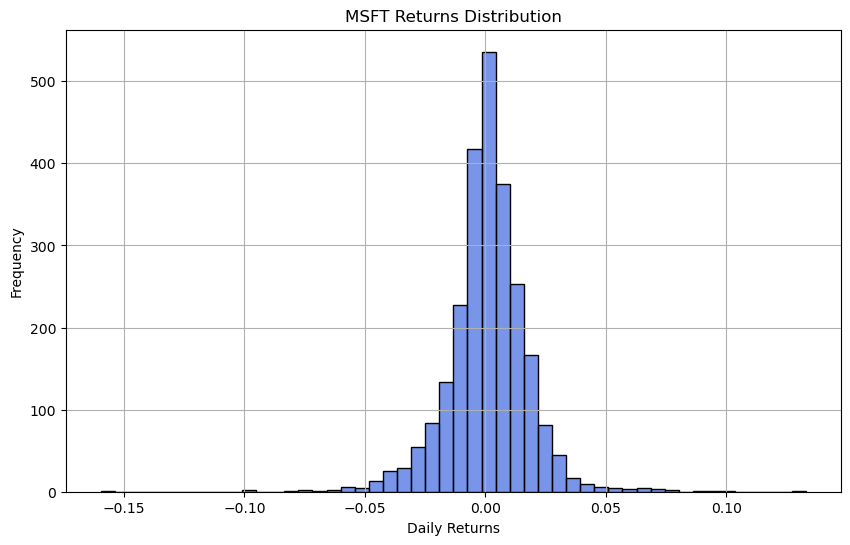

In [335]:
# Create a Simple Histogram
plt.figure(figsize=(10,6))
sns.histplot(
    data=returns_df,            # DataFrame we will use 
    x="MSFT",                   # Stock we want to plot
    bins=50,                    # Number of Ranges
    color="royalblue",          # Color
    kde=False,                  # True if you want to see the density function
    alpha=0.7,
)

plt.title("MSFT Returns Distribution")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.grid()
plt.show()

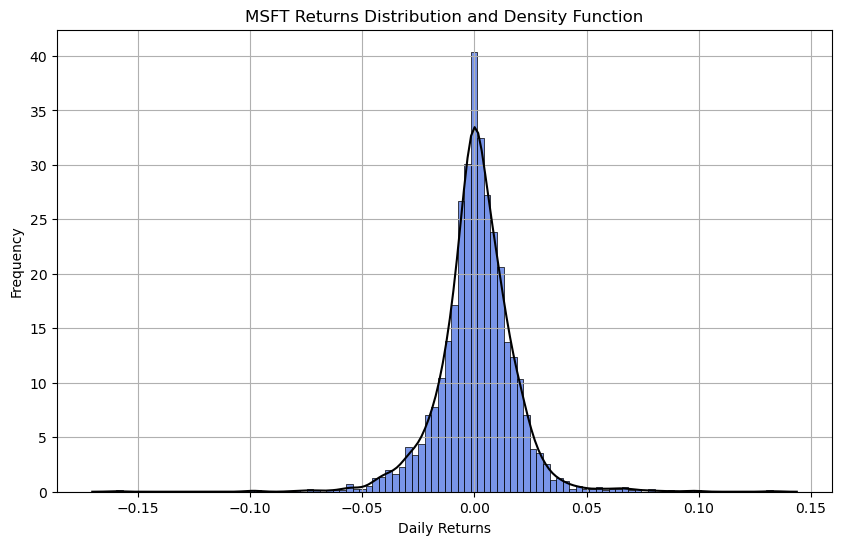

In [336]:
# Add a Density Function to the Plot
fig, ax = plt.subplots(figsize=(10,6))

# Histogram
sns.histplot(
    returns_df["MSFT"], 
    bins=100, 
    stat='density',
    color="royalblue", 
    alpha=0.7, 
    ax=ax, 
    kde=False
)

# Density Function
sns.kdeplot(
    returns_df["MSFT"], 
    ax=ax, 
    color='black', 
    linewidth=1.5
)

plt.title("MSFT Returns Distribution and Density Function")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.grid()
plt.show()

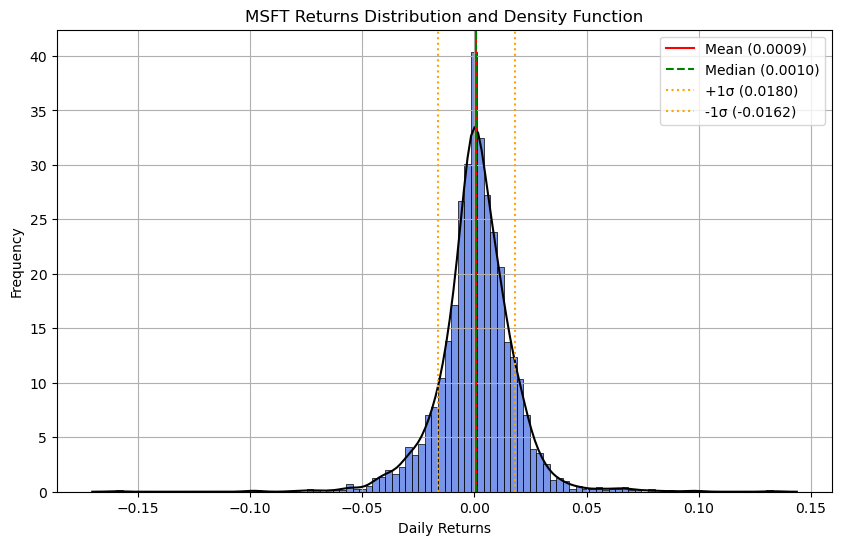

In [337]:
# Add the statistics
fig, ax = plt.subplots(figsize=(10,6))

# Histogram
sns.histplot(
    returns_df["MSFT"], 
    bins=100, 
    stat='density',
    color="royalblue", 
    alpha=0.7, 
    ax=ax, 
    kde=False
)

# Density Function
sns.kdeplot(
    returns_df["MSFT"], 
    ax=ax, 
    color='black', 
    linewidth=1.5
)

# Statistics
mean = returns_df["MSFT"].mean()
median = returns_df["MSFT"].median()
std = returns_df["MSFT"].std()

ax.axvline(mean, color='red', linestyle='-', linewidth=1.5, label=f"Mean ({mean:.4f})")
ax.axvline(median, color='green', linestyle='--', linewidth=1.5, label=f"Median ({median:.4f})")
ax.axvline(mean+std, color='orange', linestyle=':', linewidth=1.5, label=f"+1σ ({mean+std:.4f})")
ax.axvline(mean-std, color='orange', linestyle=':', linewidth=1.5, label=f"-1σ ({mean-std:.4f})")


plt.title("MSFT Returns Distribution and Density Function")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [338]:
factor_coefficients = pd.read_csv(r"../additional_data/ff_coefficients.csv")
factor_coefficients = factor_coefficients.rename(columns={'Unnamed: 0': 'stocks'})
factor_coefficients.set_index('stocks', inplace=True)

factor_coefficients

,mkt_beta,smb_beta,hml_beta,wml_beta
stocks,,,,
A,1.128971,0.207682,-0.257203,-0.099570
AAL,1.325925,0.726714,0.761726,-0.440680
AAP,0.795798,0.324448,0.220186,-0.050758
AAPL,1.150409,-0.149558,-0.453476,0.034337
ABBV,0.653552,-0.264476,0.110161,0.068886
...,...,...,...,...
YUM,0.782385,-0.074496,0.143775,0.038774
ZBH,0.767193,0.112810,0.098739,-0.097623
ZBRA,1.069888,0.527373,-0.183733,-0.124856


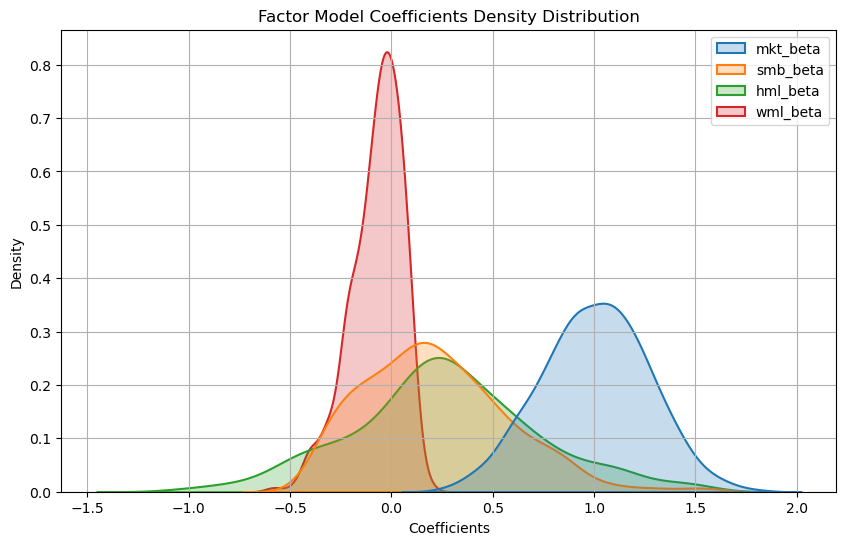

In [339]:
# Compare Density Functions
fig, ax = plt.subplots(figsize=(10,6))

# Density Function
sns.kdeplot(
    factor_coefficients,            # DataFrame to Plo  t
    ax=ax,                          # Ax
    linewidth=1.5,                  # Line Width
    fill = True,                    # Fill under the curve
)

plt.title("Factor Model Coefficients Density Distribution")
plt.xlabel("Coefficients")
plt.ylabel("Density")
plt.grid()
plt.show()

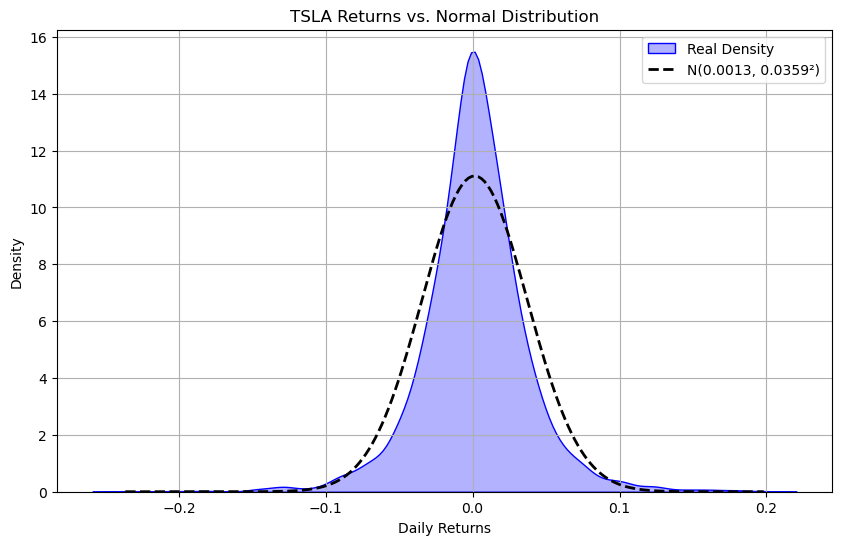

In [340]:
# Plot and Compare with Normal Distribution
data = returns_df["TSLA"].dropna()

# Calculate the Parameters
mu, sigma = data.mean(), data.std()

# Range to Graph
x = np.linspace(data.min(), data.max(), 200)
normal_pdf = norm.pdf(x, mu, sigma)

# Plot
plt.figure(figsize=(10,6))

# KDE (Observed Data)
sns.kdeplot(
    data=data,
    color="blue",
    fill=True,
    alpha=0.3,
    label="Real Density"
)

# KDE for Normal Data
plt.plot(
    x, normal_pdf, 
    color="black", 
    linestyle="--", 
    linewidth=2,
    label=f"N({mu:.4f}, {sigma:.4f}²)"
)

plt.title("TSLA Returns vs. Normal Distribution")
plt.xlabel("Daily Returns")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

### Alternative Distributions ###

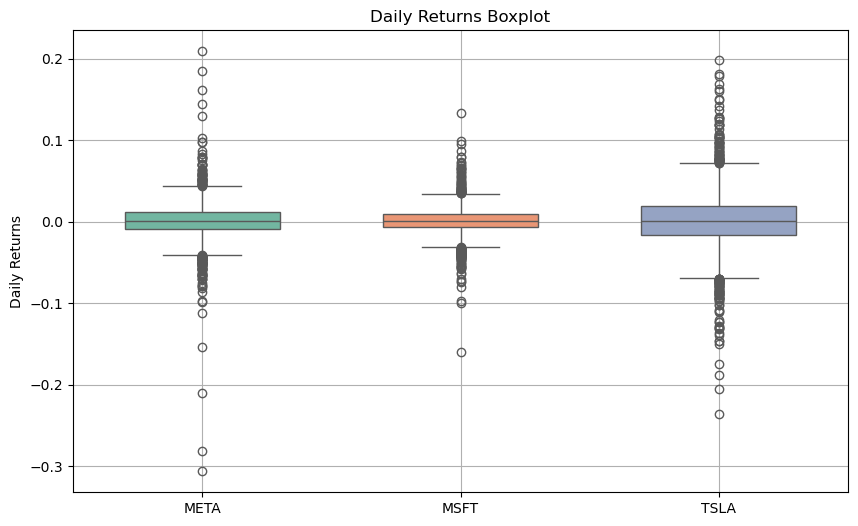

In [341]:
# BoxPlots
plt.figure(figsize=(10,6))
sns.boxplot(
    data=returns_df,
    palette="Set2",
    width=0.6,
)
plt.title("Daily Returns Boxplot")
plt.ylabel("Daily Returns")
plt.grid()
plt.show()

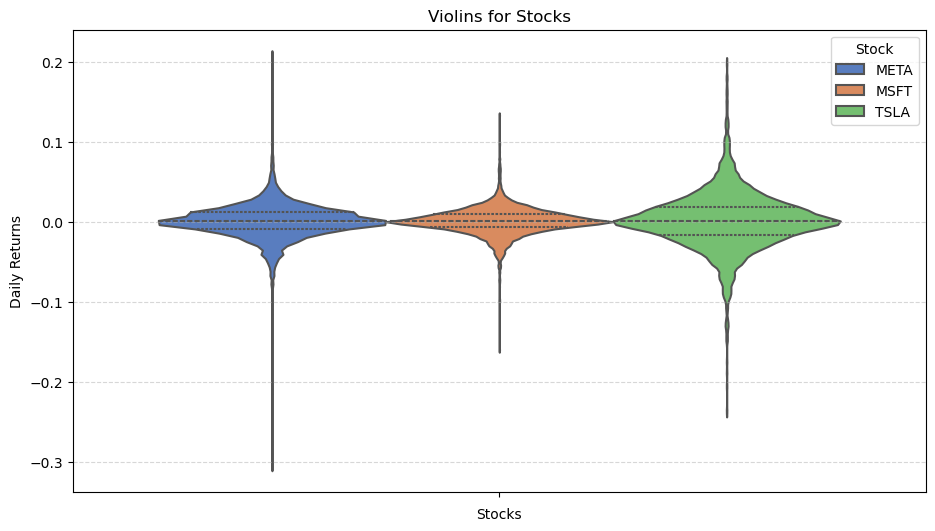

In [342]:
# Violin Plot

# Melt the Data
returns_long = returns_df.melt(var_name="Stock", value_name="Return")

# Create Plot
plt.figure(figsize=(11,6))
sns.violinplot(
    data=returns_long,              # DataFrame to use
    hue="Stock",                    # Categorization
    y="Return",                     # Variable for the Distribution
    inner="quart",                  # Inside the Violin
    palette="muted",                # Palette
    bw_adjust=0.5,                  # Smoothing distribution
    linewidth=1.5,                  # Lines Width
    dodge=True,                     # Dodge Overlapping
)

plt.title("Violins for Stocks")
plt.xlabel("Stocks")
plt.ylabel("Daily Returns")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Comparison ###

In [343]:
benchmark = pd.read_csv(r"../additional_data/benchmark_returns.csv")
benchmark.set_index('Date', inplace=True)
benchmark.index = pd.to_datetime(benchmark.index)
benchmark = benchmark.loc[returns_df.index]

In [344]:
returns_df['SP500'] = benchmark
returns_df

,META,MSFT,TSLA,SP500
2015-01-05,-0.016191,-0.009238,-0.042950,-0.018447
2015-01-06,-0.013565,-0.014786,0.005648,-0.008933
2015-01-07,0.000000,0.012625,-0.001563,0.011563
2015-01-08,0.026309,0.028994,-0.001566,0.017730
2015-01-09,-0.005644,-0.008441,-0.018981,-0.008439
...,...,...,...,...
2024-12-24,0.013084,0.009330,0.070991,0.010982
2024-12-26,-0.007266,-0.002781,-0.017787,-0.000406
2024-12-27,-0.005885,-0.017453,-0.050745,-0.011117
2024-12-30,-0.014391,-0.013328,-0.033569,-0.010760


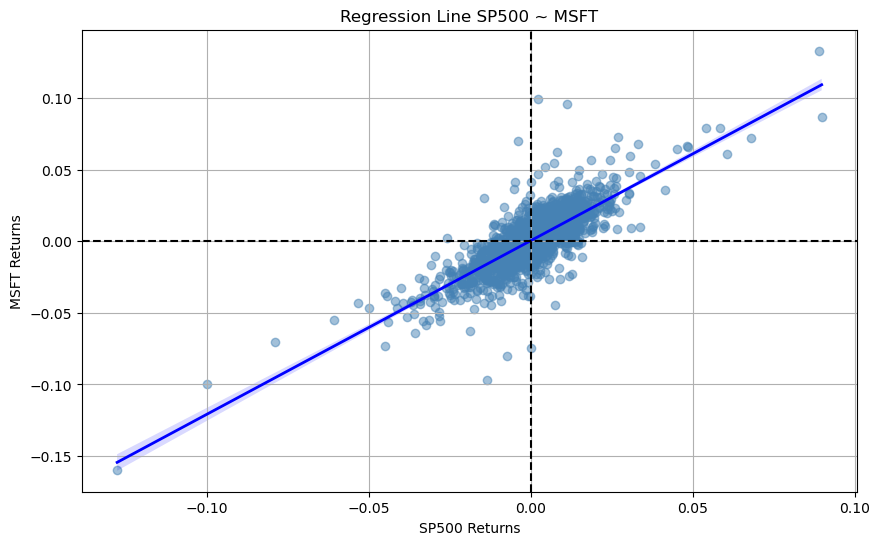

In [345]:
# Scatter Plot with Regression Line
plt.figure(figsize=(10,6))
sns.regplot(
    data=returns_df,                                            # DataFrame
    x="SP500",                                                  # X-Variable
    y="MSFT",                                                   # Y-Variable
    scatter_kws={"alpha":0.5, "color":"steelblue"},             # Scatter Points
    line_kws={"color":"blue", "lw":2},                          # Regression Line
    ci=95                                                       # Confidence Interval
)

# Vertical and Horizontal Lines
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

plt.title("Regression Line SP500 ~ MSFT")
plt.xlabel("SP500 Returns")
plt.ylabel("MSFT Returns")
plt.grid()
plt.show()

<Figure size 1000x600 with 0 Axes>

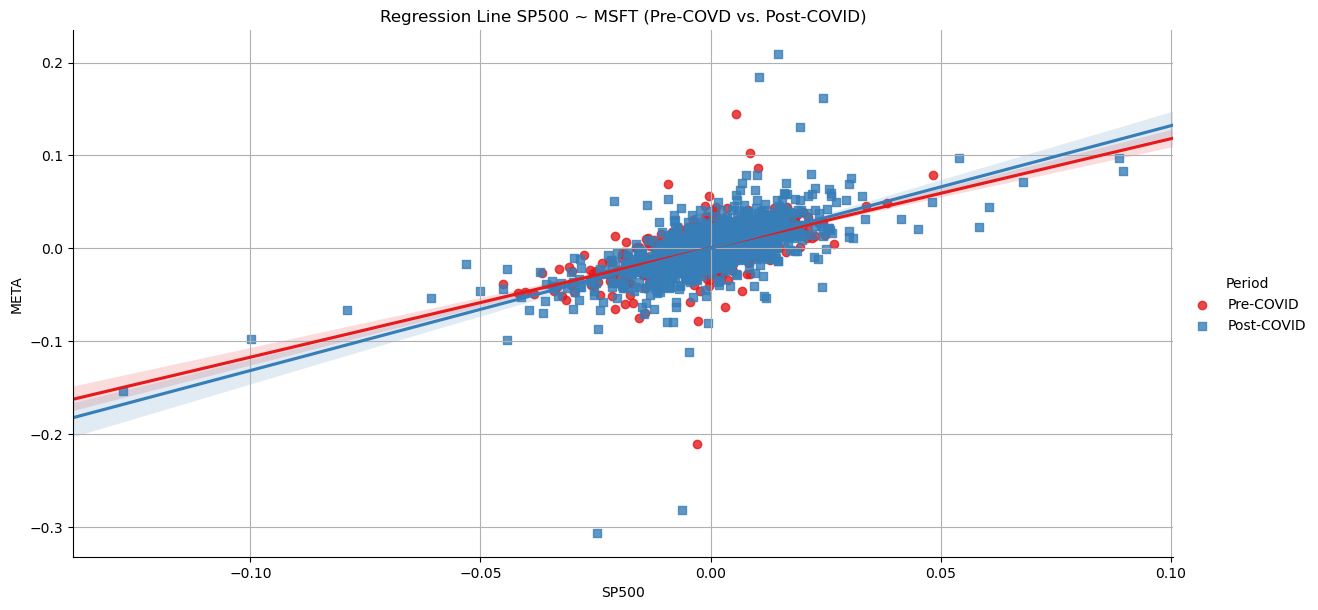

In [346]:
# Implot

# Create a Variable for Pre-COVID and Post-COVID
returns_df["Period"] = np.where(returns_df.index < "2020-03-01", "Pre-COVID", "Post-COVID")

# Plot
plt.figure(figsize=(10,6))
sns.lmplot(
    data=returns_df,    # DataFrame
    x="SP500",          # X-Variable
    y="META",           # Y-Variable
    hue="Period",       # Colors
    markers=["o","s"],  # Simbols
    palette="Set1",     # Palette
    height=6,           # Height
    aspect=2,           # Height/Length Ratio
    truncate=False,     # Truncate Lines
    ci=95,              # Confidence Interval,
)
plt.title("Regression Line SP500 ~ MSFT (Pre-COVD vs. Post-COVID)")
plt.grid()
plt.show()

In [347]:
returns_df['Year'] = returns_df.index.year

returns_df

,META,MSFT,TSLA,SP500,Period,Year
2015-01-05,-0.016191,-0.009238,-0.042950,-0.018447,Pre-COVID,2015
2015-01-06,-0.013565,-0.014786,0.005648,-0.008933,Pre-COVID,2015
2015-01-07,0.000000,0.012625,-0.001563,0.011563,Pre-COVID,2015
2015-01-08,0.026309,0.028994,-0.001566,0.017730,Pre-COVID,2015
2015-01-09,-0.005644,-0.008441,-0.018981,-0.008439,Pre-COVID,2015
...,...,...,...,...,...,...
2024-12-24,0.013084,0.009330,0.070991,0.010982,Post-COVID,2024
2024-12-26,-0.007266,-0.002781,-0.017787,-0.000406,Post-COVID,2024
2024-12-27,-0.005885,-0.017453,-0.050745,-0.011117,Post-COVID,2024
2024-12-30,-0.014391,-0.013328,-0.033569,-0.010760,Post-COVID,2024


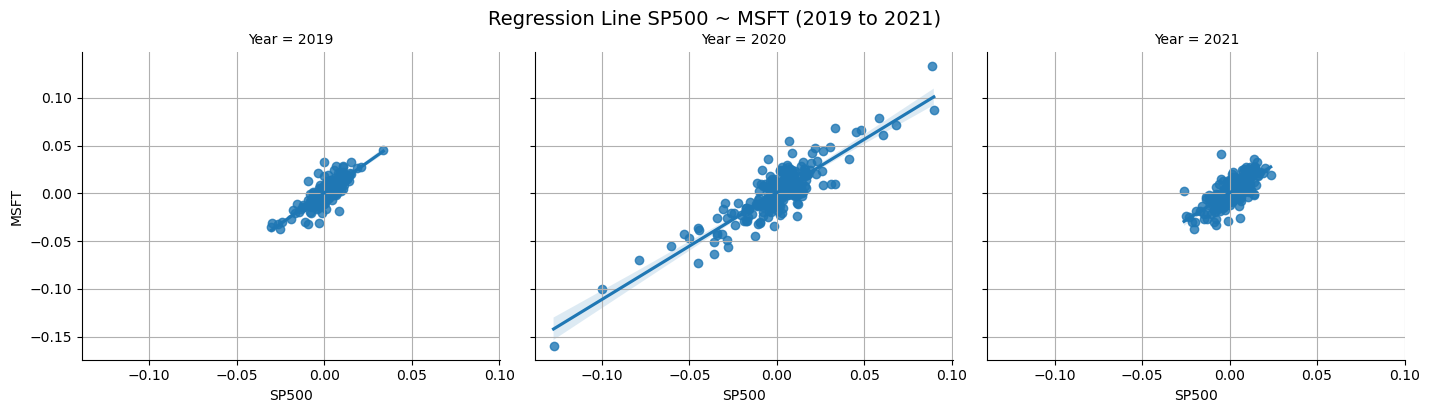

In [348]:
# Separate Columns
g = sns.lmplot(
    data=returns_df.loc['2019':'2021'],     # DataFrame
    x="SP500",                              # X-Variable
    y="MSFT",                               # Y-Variable
    col="Year",                             # Columns Variable
    height=4,                               # Height
    aspect=1.2,                             # Height/Length Ratio
    truncate=True,                          # Truncate Line
)

# General Title
g.fig.suptitle("Regression Line SP500 ~ MSFT (2019 to 2021)", fontsize=14, y=1.02)

# Add Grid to each subplot
for ax in g.axes.flatten():
    ax.grid(True)

plt.show()

In [349]:
# Create data for Pair Plot
premiums = pd.read_csv(r"../additional_data/ff_size_n_value.csv")
premiums.set_index('date', inplace=True)
premiums.index = pd.to_datetime(premiums.index)
premiums = premiums.loc[returns_df.index]

premiums

,mkt,smb,hml
2015-01-05,-0.0184,0.0033,-0.0068
2015-01-06,-0.0103,-0.0080,-0.0029
2015-01-07,0.0119,0.0020,-0.0067
2015-01-08,0.0181,-0.0012,-0.0029
2015-01-09,-0.0085,0.0001,-0.0047
...,...,...,...
2024-12-24,0.0111,-0.0009,-0.0006
2024-12-26,0.0001,0.0104,-0.0019
2024-12-27,-0.0117,-0.0065,0.0057
2024-12-30,-0.0109,0.0013,0.0074


In [350]:
concat = pd.concat([premiums, returns_df['MSFT']], axis = 1)

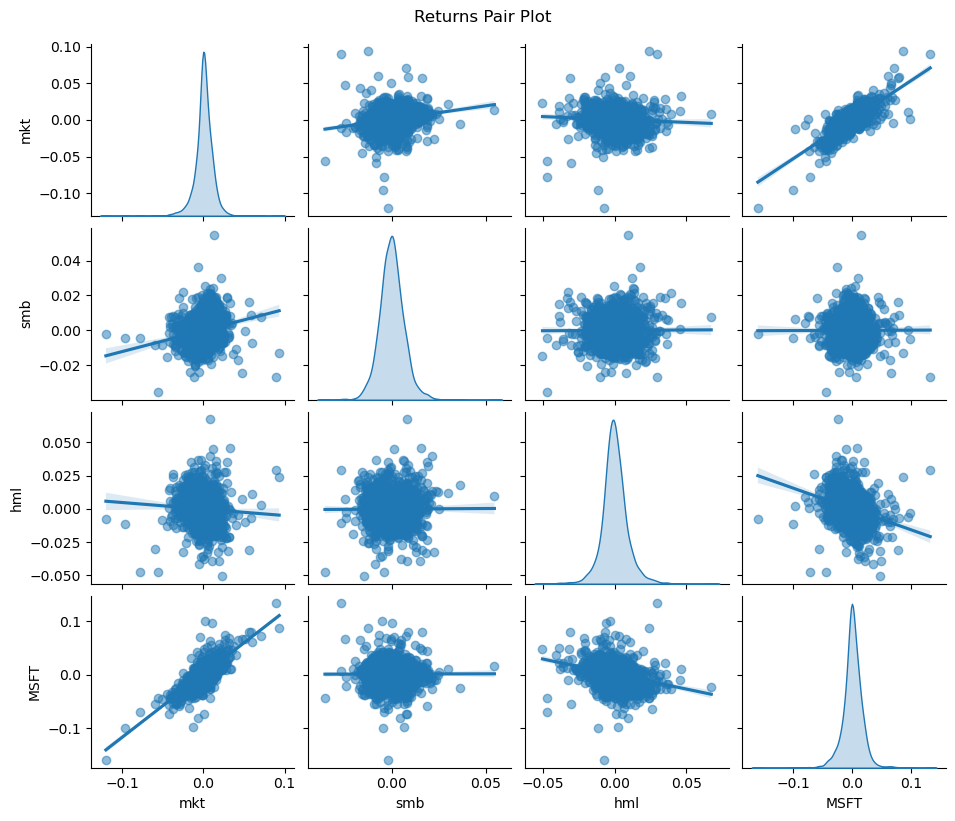

In [351]:
# Pair Plot
sns.pairplot(
    data=concat,                                # DataFrame
    kind="reg",                                 # Tendency Line
    diag_kind="kde",                            # Density Plot in Diagonal
    plot_kws={"scatter_kws":{"alpha":0.5}},     # Characteristics
    height=2, 
    aspect=1.2, 
)

plt.suptitle("Returns Pair Plot", y=1.02)
plt.show()

# Heatmaps #

In [352]:
etf_tickers = get_tickers("7.2b")

etf_tickers

['XLC', 'XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLB', 'XLRE', 'XLK', 'XLU']

In [353]:
# DataFrame to store everything
etf_returns = pd.DataFrame()

for ticker in etf_tickers:
    df_stock = get_market_data(
        ticker=ticker, 
        start_date='2019-01-01', 
        end_date='2025-01-01', 
        returns=True
    )
    
    returns = df_stock['returns'].rename(ticker)
    
    etf_returns = pd.concat([etf_returns, returns], axis=1)

In [354]:
# Dates
etf_returns.index = pd.to_datetime(etf_returns.index)
etf_returns

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
2019-01-03,-0.016876,-0.021890,-0.005761,-0.009967,-0.022738,-0.020514,-0.030902,-0.028767,0.004611,-0.051786,-0.000192
2019-01-04,0.042134,0.032558,0.021095,0.033458,0.032680,0.029394,0.037215,0.038565,0.010136,0.043366,0.014699
2019-01-07,0.011357,0.022360,-0.001366,0.014756,0.001236,0.003832,0.008102,0.003504,0.008423,0.008903,-0.006846
2019-01-08,0.016684,0.010995,0.009139,0.007706,0.000823,0.007734,0.013610,0.010439,0.017269,0.008345,0.012326
2019-01-09,0.001359,0.005071,-0.009335,0.015718,0.004924,0.004475,0.006736,0.000384,-0.004130,0.012863,-0.006049
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.009422,0.022864,0.006567,0.008424,0.011703,0.004100,0.007782,0.005393,0.006638,0.010280,0.005507
2024-12-26,-0.001312,-0.003717,0.003142,-0.000827,0.002446,0.002008,0.000745,-0.001521,0.001469,0.000665,-0.002356
2024-12-27,-0.008925,-0.016662,-0.004906,-0.000118,-0.007357,-0.004667,-0.007476,-0.005401,-0.008107,-0.013384,-0.002888
2024-12-30,-0.010549,-0.016192,-0.011797,-0.000118,-0.009688,-0.012383,-0.010106,-0.013512,-0.004698,-0.012798,-0.004215


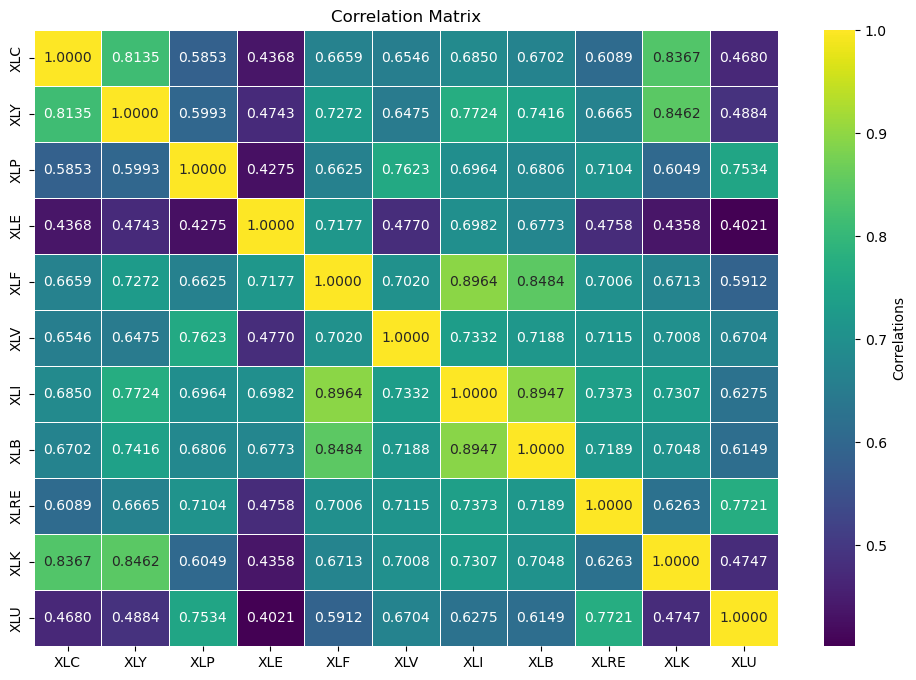

In [355]:
# Correlation Matrix Heat Map
corr_matrix = etf_returns.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,                        # Correlation Matrix
    annot=True,                         # Show Values in each Cell
    fmt=".4f",                          # Decimals Format
    cmap="viridis",                     # Palette
    linewidths=0.5,                     # Lines between cells
    cbar_kws={"label":"Correlations"}   # Color Bar
)
plt.title("Correlation Matrix")
plt.show()

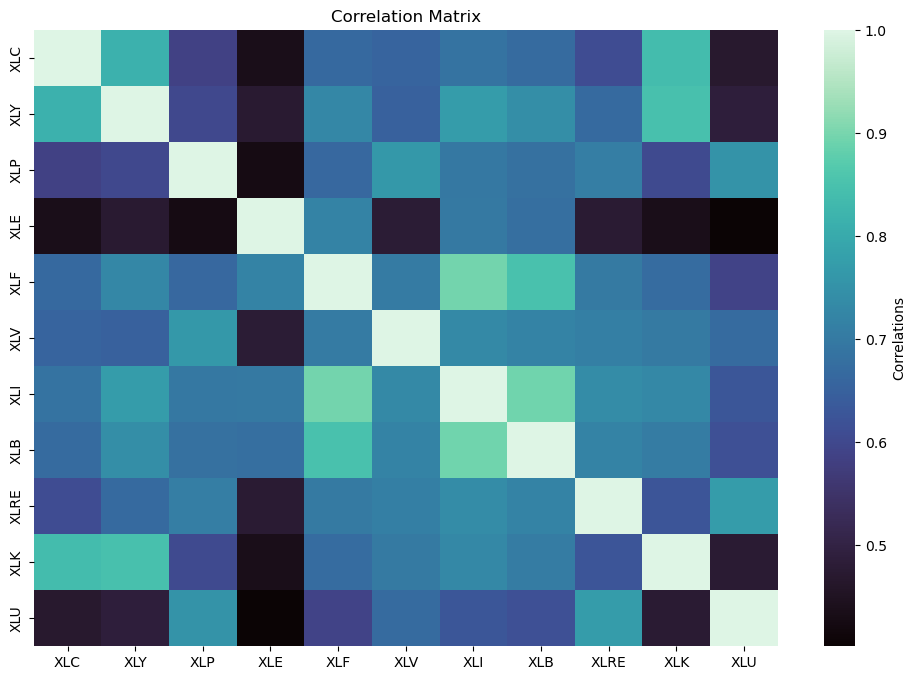

In [356]:
# Correlation Matrix Heat Map with no Notations
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,                                # Correlation Matrix
    cmap='mako',                                # Palette
    linewidths=0,                               # Lines between cells
    cbar_kws={"label":"Correlations"}           # Color Bar
)
plt.title("Correlation Matrix")
plt.show()

### Palettes ###

In [357]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [358]:
sns.color_palette("hls", 16)

[(0.86, 0.3712, 0.33999999999999997),
 (0.86, 0.5661999999999999, 0.33999999999999997),
 (0.86, 0.7612000000000001, 0.33999999999999997),
 (0.7638, 0.86, 0.33999999999999997),
 (0.5688000000000001, 0.86, 0.33999999999999997),
 (0.3738000000000001, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.5012000000000001),
 (0.33999999999999997, 0.86, 0.6962000000000002),
 (0.33999999999999997, 0.8287999999999999, 0.86),
 (0.33999999999999997, 0.6337999999999998, 0.86),
 (0.33999999999999997, 0.43879999999999986, 0.86),
 (0.43619999999999975, 0.33999999999999997, 0.86),
 (0.6311999999999998, 0.33999999999999997, 0.86),
 (0.8261999999999998, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.6987999999999996),
 (0.86, 0.33999999999999997, 0.5037999999999996)]

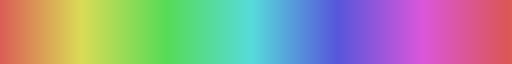

In [359]:
sns.color_palette("hls", as_cmap=True)

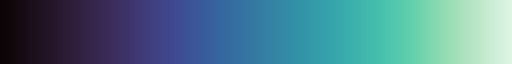

In [360]:
sns.color_palette("mako", as_cmap=True)

In [361]:
sns.color_palette("mako")

[(0.18195582, 0.11955283, 0.23136943),
 (0.25307401, 0.23772973, 0.48316271),
 (0.21607792, 0.39736958, 0.61948028),
 (0.20344718, 0.56074869, 0.65649508),
 (0.25187832, 0.71827158, 0.67872193),
 (0.54578602, 0.8544913, 0.69848331)]

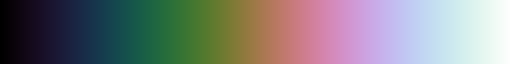

In [362]:
sns.color_palette("cubehelix", as_cmap=True)

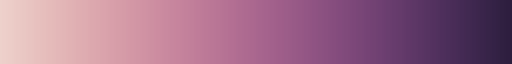

In [363]:
sns.cubehelix_palette(as_cmap=True)

Check more Palettes and Colors in the Seaborn Website: "https://seaborn.pydata.org/tutorial/color_palettes.html"

### Styles ###

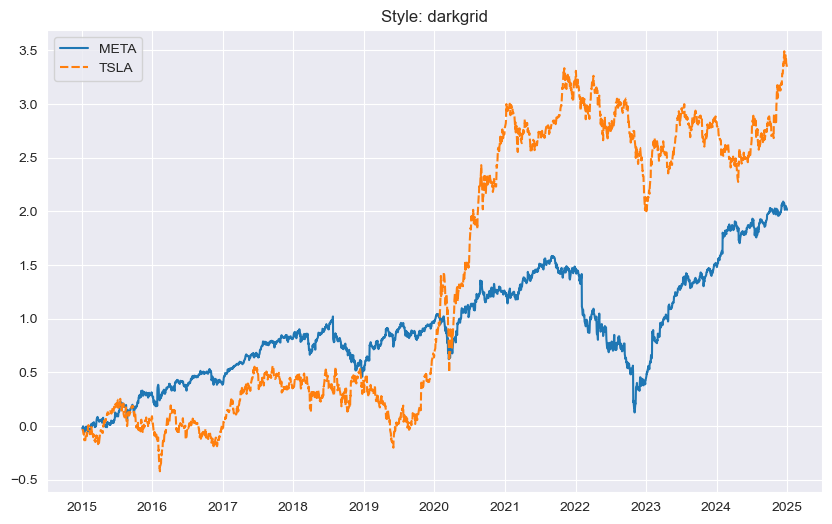

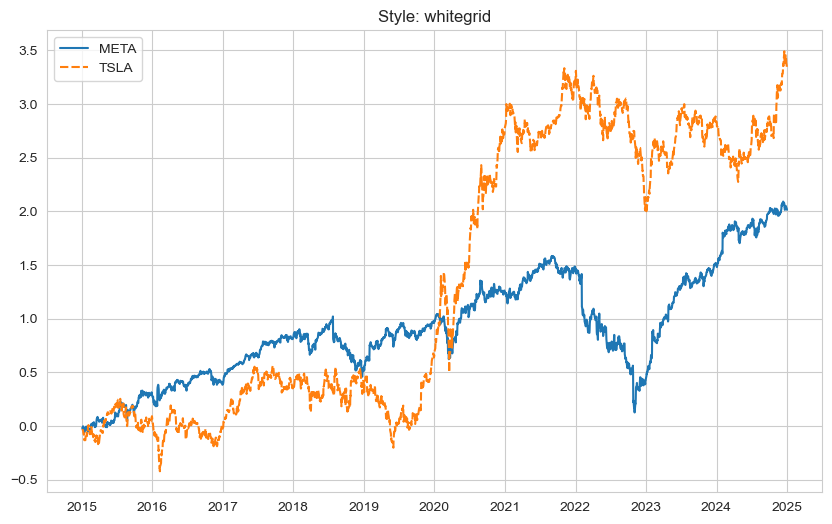

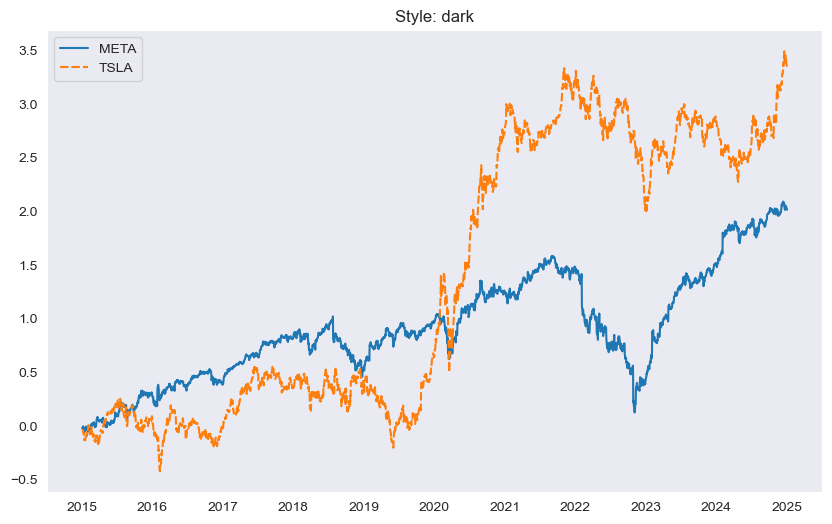

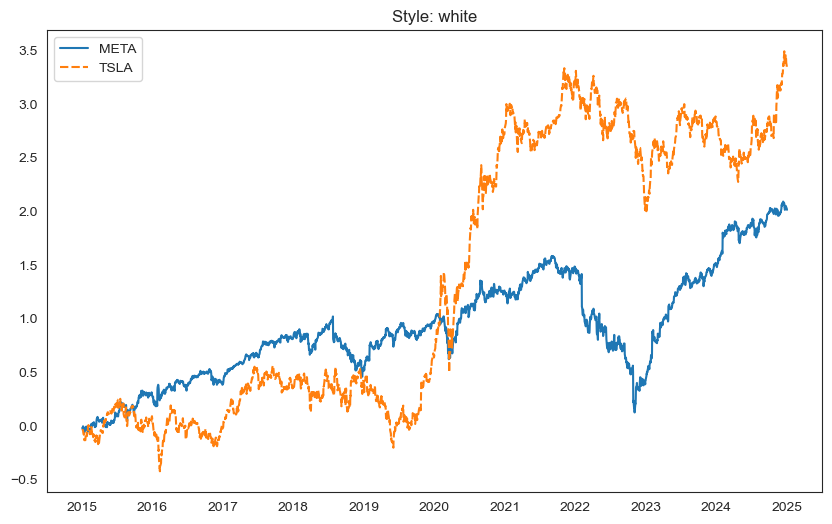

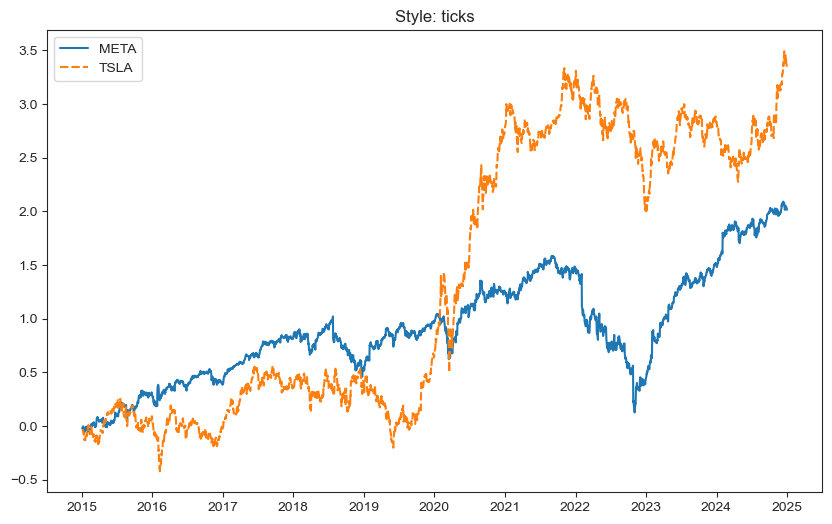

In [369]:
# Test Styles
for style in ["darkgrid", "whitegrid", "dark", "white", "ticks"]:
    sns.set_style(style)
    plt.figure(figsize=(10,6))
    sns.lineplot(data=returns_df[["META","TSLA"]].cumsum())
    plt.title(f"Style: {style}")
    plt.show()

Check more Styles tn the Seaborn Website: "https://seaborn.pydata.org/tutorial/aesthetics.html"